In [ ]:
import torch
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
sys.path.append('../')
from utilities import load_embedding, print_exams
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from IPython.display import clear_output
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from joblib import Parallel, delayed
from tqdm import tqdm


In [22]:
class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def monte_carlo_preds(model, dataloader, emb_dict, device, T=20):
    all_preds = []
    all_labels = []
    seed_base = 42
    model.train()
    Total_iter = T*len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Monte Carlo Predictions")
    for t in range(T):
        for batch in dataloader:
            with torch.no_grad():
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]
                matrixs_a, matrixs_b, matrixs_c, matrixs_d= matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)

                torch.manual_seed(seed_base + t)
                torch.cuda.manual_seed_all(seed_base + t)
                
                _, _, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                all_preds.append([item[0].item() for item in output])
                all_labels.append(labels)
                progress_bar.update(1)
    
    progress_bar.close()
    return all_preds, all_labels

def multidata_trainer(model, train_dataloader, valid_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    valid_MAE_ls = []
    valid_MSE_ls = []
    valid_Pearson_ls = []
    valid_Spearman_ls = []
    test_MAE_ls = []
    test_MSE_ls = []
    test_Pearson_ls = []
    test_Spearman_ls = []
    Pearson_ls = []
    Spearman_ls = []
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        valid_prediction_ls = []
        valid_reference_ls = []
        valid_logits_ls = []
        model.eval()
        for batch in valid_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            valid_prediction_ls = valid_prediction_ls + output.view(-1).tolist()
            valid_reference_ls = valid_reference_ls + labels.tolist()
            valid_logits_ls.append(logits.tolist())
        
        valid_mae, valid_mse, valid_pearson, valid_spearman, R2 = print_exams(valid_reference_ls, valid_prediction_ls, print_result=False)
        valid_MAE_ls.append(valid_mae)
        valid_MSE_ls.append(valid_mse)
        valid_Pearson_ls.append(valid_pearson)
        valid_Spearman_ls.append(valid_spearman)

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls, print_result=False)
        test_MAE_ls.append(test_mae)
        test_MSE_ls.append(test_mse)
        test_Pearson_ls.append(test_pearson)
        test_Spearman_ls.append(test_spearman)


        epochs = list(range(1, len(valid_MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, valid_MSE_ls, label='valid MSE', marker='o')
        plt.plot(epochs, test_MSE_ls, label='test MSE', marker='x')

        plt.text(epochs[-1], valid_MSE_ls[-1], f'{valid_MSE_ls[-1]:.5f}', ha='center', va='bottom')
        plt.text(epochs[-1], test_MSE_ls[-1], f'{test_MSE_ls[-1]:.5f}', ha='center', va='top')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [test_MAE_ls, test_MSE_ls, test_Pearson_ls, test_Spearman_ls, R2]

def elbow_method(data, K_min=5, K_max=300, step=5, n_jobs=-1, random_state=42, figsize=(12, 6)):
    """
    使用肘部法则 (Elbow Method) 绘制不同 K 值下的 SSE 曲线

    参数
    ----------
    data : ndarray
        输入的数据矩阵 (样本数 × 特征数)
    K_min : int, default=5
        K 的最小值
    K_max : int, default=300
        K 的最大值
    step : int, default=5
        K 的步长
    n_jobs : int, default=-1
        并行计算时的 CPU 核心数，-1 表示使用所有核心
    random_state : int, default=42
        随机种子
    figsize : tuple, default=(12, 6)
        绘图大小
    """

    K_range = range(K_min, K_max + 1, step)

    def compute_sse(K):
        kmeans = KMeans(n_clusters=K, random_state=random_state)
        kmeans.fit(data)
        return kmeans.inertia_

    sse = Parallel(n_jobs=n_jobs)(delayed(compute_sse)(K) for K in K_range)

    # 绘制图像
    plt.figure(figsize=figsize)
    plt.plot(K_range, sse, marker='o')
    plt.title(f'Elbow Method (K={K_min}-{K_max}, step={step})')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('SSE (Sum of Squared Errors)')
    plt.grid(True)
    plt.show()

def retrive_feature_vector(model, dataloader, emb_dict, device, emb_in_device=False, save_path=None):
    model.eval()
    Total_iter = len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Retrive Feature Vector")
    for batch in dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
        matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_d])

        if emb_in_device == False:
            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)

        masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
        strainPassCats, labels = strainPassCats.to(device), labels.to(device)
        
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                        save_concat_vector=save_path)

        progress_bar.update(1)
    progress_bar.close()


In [24]:
device = torch.device('cuda:2')
Crick_train = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/train.csv', index_col=False)
Crick_test = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/test.csv', index_col=False)
Active_data = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/CNIC_all.csv', index_col=False)
Active_data = Active_data.loc[Active_data['virusDate'] <= '2023-08-31']

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Active_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Active_final = Active_data.groupby(group_columns).agg(agg_dict).reset_index()

Active_final['seq_id_a'] = Active_final['seq_id_a'] + '_active'
Active_final['seq_id_b'] = Active_final['seq_id_b'] + '_active'
Active_final['seq_id_c'] = Active_final['seq_id_c'] + '_active'
Active_final['seq_id_d'] = Active_final['seq_id_d'] + '_active'

serums = Active_final[['seq_id_a', 'seq_id_b', 'serumPassCat']].value_counts().reset_index()
serums = serums[serums['count'] >=20]
Active_final = serums[['seq_id_a', 'seq_id_b', 'serumPassCat']].merge(Active_final, on=['seq_id_a', 'seq_id_b', 'serumPassCat'])

Active_candidate, Active_test = train_test_split(Active_final, test_size=0.1, random_state=42)
# Active_candidate, Active_valid = train_test_split(Active_candidate, test_size=1/9, random_state=42)

Active_candidate = Active_candidate.reset_index(drop=True)

In [35]:
Active_final.shape

(12794, 22)

In [25]:
batch_size = 256
Crick_train_dataloader = DataLoader(fluProfiler_Dataset(Crick_train), batch_size=batch_size, shuffle=True)
Crick_test_dataloader = DataLoader(fluProfiler_Dataset(Crick_test), batch_size=batch_size, shuffle=False)
Active_candidate_dataloader = DataLoader(fluProfiler_Dataset(Active_candidate), batch_size=batch_size, shuffle=False)
# Active_valid_dataloader = DataLoader(fluProfiler_Dataset(Active_valid), batch_size=batch_size, shuffle=False)
Active_test_dataloader = DataLoader(fluProfiler_Dataset(Active_test), batch_size=128, shuffle=False)

In [5]:
# load embedding
emb_dict_active = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_CNIC")
emb_dict_active = {key:value.to(device) for key, value in emb_dict_active.items()}

Loading tensor: 100%|██████████| 1958/1958 [01:30<00:00, 21.55file/s]


## 使用聚类筛选代表性样本

In [6]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
retrive_feature_vector(model, Active_candidate_dataloader, emb_dict_active, device, emb_in_device=True, save_path='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC')

Retrive Feature Vector: 100%|██████████| 45/45 [00:51<00:00,  1.14s/it]


In [26]:
dict_path = '/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CNIC'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=False))
active_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()

In [27]:
import numpy as np
from sklearn.cluster import KMeans

# 假设 active_candidate_tensor 已经是 numpy 数组，shape = (N, 1024)
X = active_candidate_tensor
serum_emb = X[:, :512]   # 血清 embedding
virus_emb = X[:, 512:]   # 病毒 embedding

# ==========
# Step 1: 分别聚类
# ==========
n_serum_clusters = 10
n_virus_clusters = 20

kmeans_serum = KMeans(n_clusters=n_serum_clusters, random_state=42, n_init=10).fit(serum_emb)
kmeans_virus = KMeans(n_clusters=n_virus_clusters, random_state=42, n_init=10).fit(virus_emb)

serum_labels = kmeans_serum.labels_
virus_labels = kmeans_virus.labels_

# ==========
# Step 2: 组合成 block
# ==========
pair_blocks = list(zip(serum_labels, virus_labels))  # 每个 pair 对应的 block (血清簇, 病毒簇)

# ==========
# Step 3: 在每个 block 里选代表性 pair
# ==========
selected_indices = []
for i in range(n_serum_clusters):
    for j in range(n_virus_clusters):
        idx = [k for k, (s, v) in enumerate(pair_blocks) if s == i and v == j]
        if len(idx) > 0:
            cluster_points = X[idx]
            center = cluster_points.mean(axis=0)
            dists = np.linalg.norm(cluster_points - center, axis=1)
            rep_idx = idx[np.argmin(dists)]
            selected_indices.append(rep_idx)

# ==========
# 输出选中的行 index
# ==========
print("选中的行数:", len(selected_indices))


选中的行数: 124


In [28]:
active_selection_final = Active_candidate.iloc[selected_indices]
random_selection_final = Active_candidate.sample(active_selection_final.shape[0], random_state=42)

In [29]:
active_dataloader = DataLoader(fluProfiler_Dataset(active_selection_final), batch_size=8, shuffle=True)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection_final), batch_size=8, shuffle=True)

In [30]:
def multidata_trainer(model, train_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    test_MAE_ls = []
    test_MSE_ls = []
    test_Pearson_ls = []
    test_Spearman_ls = []
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls, print_result=False)
        test_MAE_ls.append(test_mae)
        test_MSE_ls.append(test_mse)
        test_Pearson_ls.append(test_pearson)
        test_Spearman_ls.append(test_spearman)


        epochs = list(range(1, len(test_MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, test_MSE_ls, label='test MSE', marker='x')

        plt.text(epochs[-1], test_MSE_ls[-1], f'{test_MSE_ls[-1]:.5f}', ha='center', va='top')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [test_MAE_ls, test_MSE_ls, test_Pearson_ls, test_Spearman_ls, R2]

In [36]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, active_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=20)

KeyboardInterrupt: 

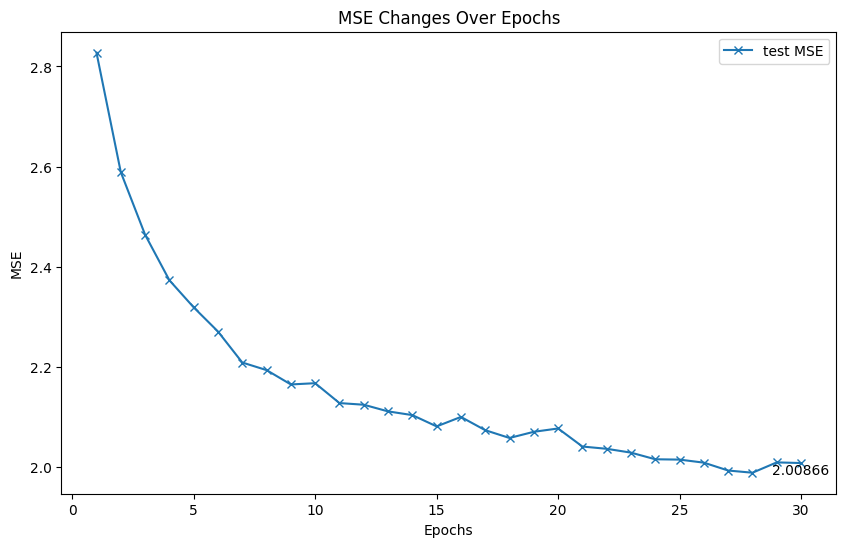

In [34]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=30)

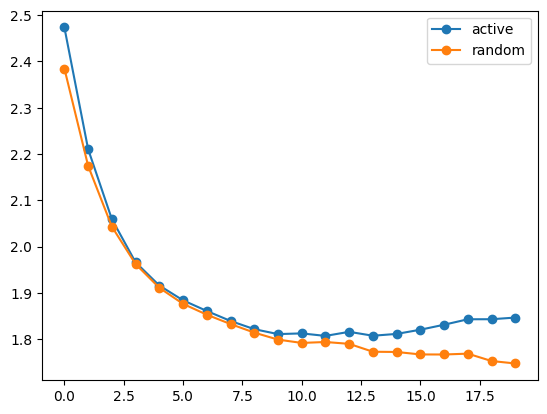

In [ ]:
plt.plot(active_result[1], label='active', marker='o')
plt.plot(random_result[1], label='random', marker='o')
plt.legend()
plt.show()